In [1]:
# # Feature Matching Demo (LoMa)

# Match keypoints between a **reference image** and a **generated multi-reference image**, using the same LoMa matcher as `sift_canvas_build.py`.

In [12]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

NOTEBOOK_DIR = Path.cwd()
LOMA_SRC = NOTEBOOK_DIR / "external" / "LoMa" / "src"
if str(LOMA_SRC) not in sys.path:
    sys.path.insert(0, str(LOMA_SRC))

from loma import LoMa, LoMaB

# Sample from stage3 metadata
SAMPLE_ID = "sample_0000008"
IMAGES_ROOT = NOTEBOOK_DIR


REF_PATH = IMAGES_ROOT / "outputs/cuisine/images/United_States/cuisine/Pie_à_la_Mode/Pie_à_la_Mode_Q7191330.jpg"
GEN_PATH = IMAGES_ROOT / "outputs/stage3_generated/images/sample_0000008.png"

print(f"Reference: {REF_PATH.name}")
print(f"Generated: {GEN_PATH.name}")

Reference: Pie_à_la_Mode_Q7191330.jpg
Generated: sample_0000008.png


In [13]:
def draw_matches_panel(
    ref_path: Path,
    gen_path: Path,
    kpts_ref: np.ndarray,
    kpts_gen: np.ndarray,
) -> Image.Image:
    ref = Image.open(ref_path).convert("RGB")
    gen = Image.open(gen_path).convert("RGB")
    w1, h1 = ref.size
    w2, h2 = gen.size
    canvas = Image.new("RGB", (w1 + w2, max(h1, h2)), (0, 0, 0))
    canvas.paste(ref, (0, 0))
    canvas.paste(gen, (w1, 0))
    draw = ImageDraw.Draw(canvas)
    rng = np.random.default_rng(0)
    for (x1, y1), (x2, y2) in zip(kpts_ref, kpts_gen):
        color = tuple(int(c) for c in rng.integers(40, 220, 3))
        draw.line([(x1, y1), (x2 + w1, y2)], fill=color, width=1)
    return canvas


def show_pair(title: str, ref_path: Path, gen_path: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(Image.open(ref_path))
    axes[0].set_title(f"Reference: {ref_path.name}")
    axes[0].axis("off")
    axes[1].imshow(Image.open(gen_path))
    axes[1].set_title(f"Generated: {gen_path.name}")
    axes[1].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

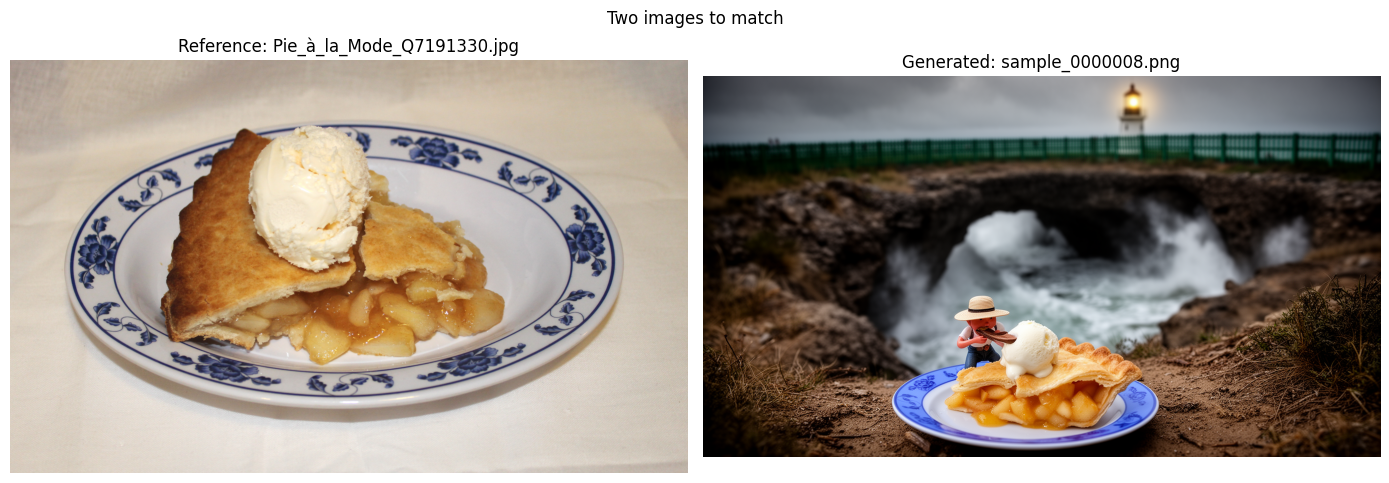

In [14]:
show_pair("Two images to match", REF_PATH, GEN_PATH)

In [16]:
print("Loading LoMa matcher...")
model = LoMa(LoMaB())

print("Running feature matching...")
kpts_ref, kpts_gen = model.match(str(REF_PATH), str(GEN_PATH))
print(f"Found {len(kpts_ref)} matches")

Loading LoMa matcher...


Running feature matching...
Found 51 matches


Saved: /mnt/data0/teja/research_multiref/synthetic_dataset_generation/outputs/stage3_generated/canvas/sample_0000008_matches_Pie_à_la_Mode_Q7191330.jpg


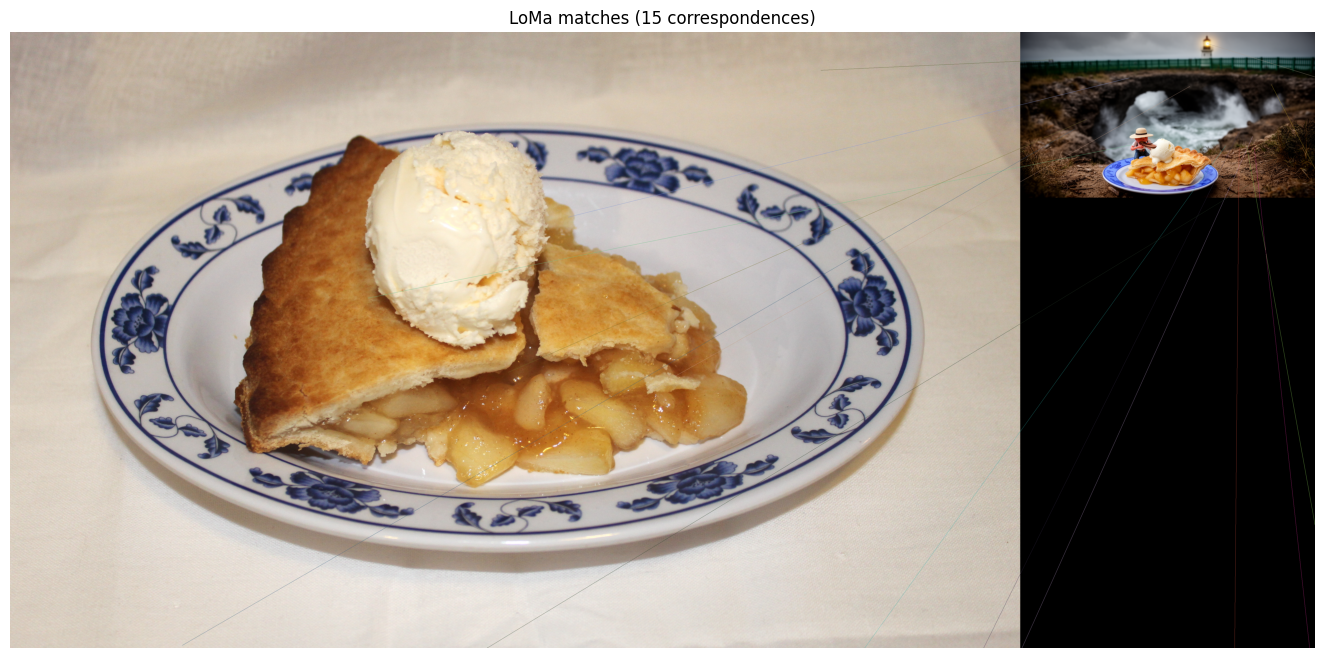

In [15]:
match_panel = draw_matches_panel(REF_PATH, GEN_PATH, kpts_ref, kpts_gen)

out_dir = NOTEBOOK_DIR / "outputs/stage3_generated/canvas"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{SAMPLE_ID}_matches_{REF_PATH.stem}.jpg"
match_panel.save(out_path, quality=92)
print(f"Saved: {out_path}")

plt.figure(figsize=(18, 8))
plt.imshow(match_panel)
plt.title(f"LoMa matches ({len(kpts_ref)} correspondences)")
plt.axis("off")
plt.show()

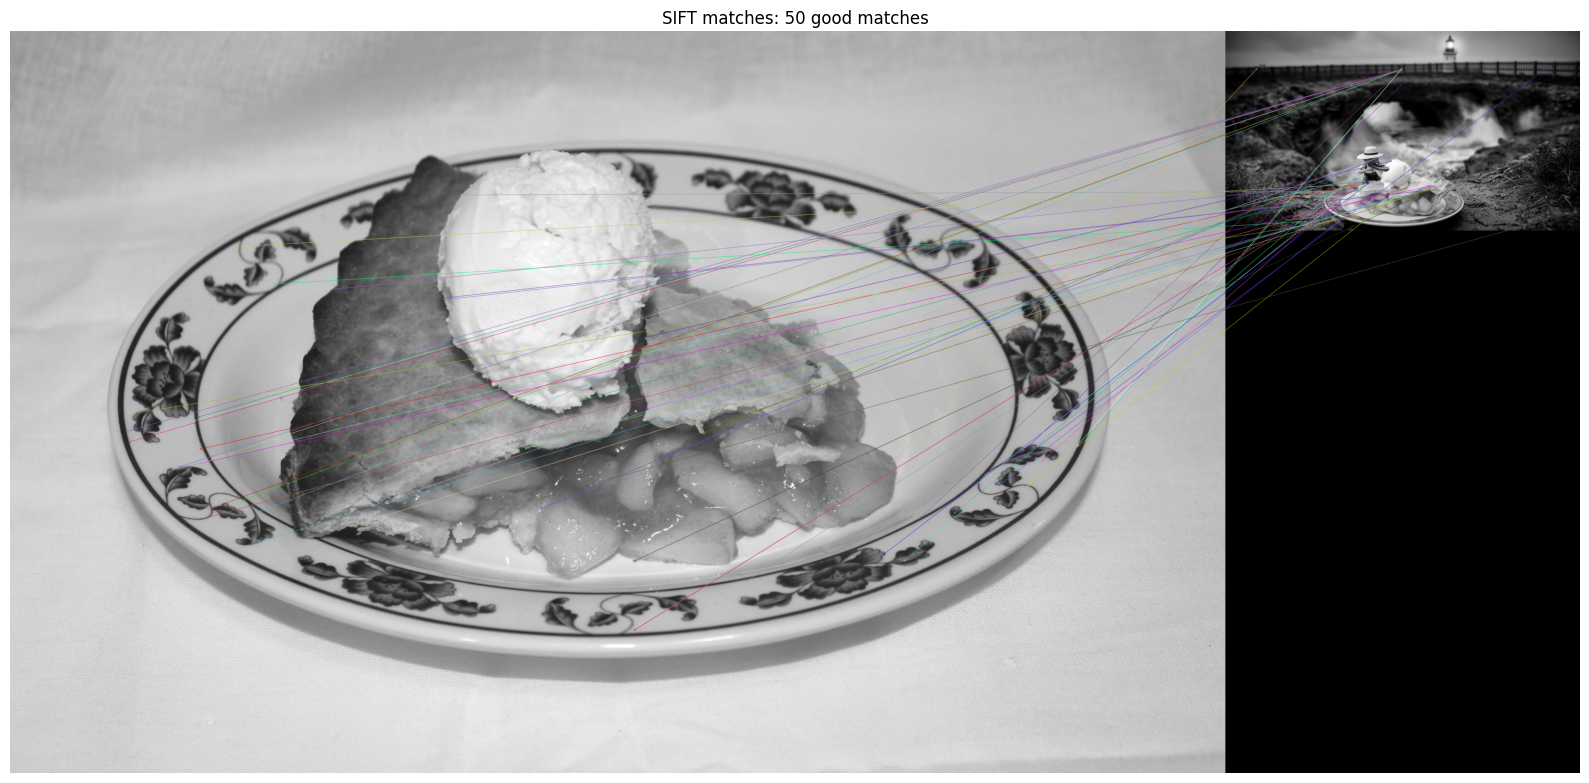

Found 50 good matches


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_gray(path: Path) -> np.ndarray:
    """Load an image as grayscale numpy array for OpenCV."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def match_features(
    ref_path: Path,
    gen_path: Path,
    method: str = "sift",   # "sift" or "orb"
    max_matches: int = 50,
    ratio_thresh: float = 0.75,
):
    """
    Detect keypoints/descriptors in both images and match them.
    Returns (img1_rgb, img2_rgb, kp1, kp2, good_matches).
    """
    gray1, rgb1 = load_gray(ref_path)
    gray2, rgb2 = load_gray(gen_path)

    if method == "sift":
        detector = cv2.SIFT_create()
        norm = cv2.NORM_L2
    elif method == "orb":
        detector = cv2.ORB_create(nfeatures=2000)
        norm = cv2.NORM_HAMMING
    else:
        raise ValueError("method must be 'sift' or 'orb'")

    kp1, des1 = detector.detectAndCompute(gray1, None)
    kp2, des2 = detector.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        raise RuntimeError("No descriptors found in one of the images.")

    # BFMatcher with ratio test (Lowe's ratio test)
    bf = cv2.BFMatcher(norm)
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for pair in matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio_thresh * n.distance:
                good.append(m)

    good = sorted(good, key=lambda m: m.distance)[:max_matches]

    return rgb1, rgb2, kp1, kp2, good


def draw_and_show_matches(ref_path: Path, gen_path: Path, method: str = "sift"):
    rgb1, rgb2, kp1, kp2, good = match_features(ref_path, gen_path, method=method)

    gray1, _ = load_gray(ref_path)
    gray2, _ = load_gray(gen_path)

    match_img = cv2.drawMatches(
        gray1, kp1, gray2, kp2, good, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16, 8))
    plt.imshow(match_img, cmap="gray")
    plt.title(f"{method.upper()} matches: {len(good)} good matches")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return good


# --- Usage with your paths ---
good_matches = draw_and_show_matches(REF_PATH, GEN_PATH, method="sift")
print(f"Found {len(good_matches)} good matches")